In [1]:
import tz_pypsa
import pandas as pd
import numpy as np
from google.cloud import bigquery
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tz_pypsa.model import Model
from tz_pypsa.constraints import (constr_max_annual_utilisation_generator, 
                                  constr_min_annual_utilisation_generator)
import tz_pypsa.wrangle as wrangle

from itables import init_notebook_mode, show   

In [2]:
n=Model.load_csv_from_dir('./stock_models/Taiwan',
                          2030,
                          frequency='1h',
                          timesteps=8760,
                          backstop=False,
                          set_global_constraints = False)

INFO:pypsa.io:Imported network Taiwan has buses, carriers, generators, loads, storage_units


In [ ]:
n.optimize.create_model()

constr_max_annual_utilisation_generator(n, carriers='Coal|LNG|Biomass|Geothermal') # Set max annual utilisation for these generators
constr_min_annual_utilisation_generator(n, carriers='Oil') # Set min annual utilisation for these generators

n.optimize.solve_model()

Index(['TWN'], dtype='object', name='Bus')


['TWN-Coal-2024active_exo', 'TWN-Coal-2030_exo', 'TWN-LNG-2024active_exo', 'TWN-LNG-2030_endo', 'TWN-LNG-2030_exo', 'TWN-Biomass-2024active_exo', 'TWN-Biomass-2030_endo', 'TWN-Biomass-2030_exo', 'TWN-Geothermal-2024active_exo', 'TWN-Geothermal-2030_endo', 'TWN-Geothermal-2030_exo']


INFO:linopy.model: Solve problem using Highs solver


['TWN-Oil-2024active_exo', 'TWN-Oil-2030_exo']


INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 6/6 [00:01<00:00,  3.27it/s]
INFO:linopy.io: Writing time: 18.52s


<Axes: xlabel='snapshot'>

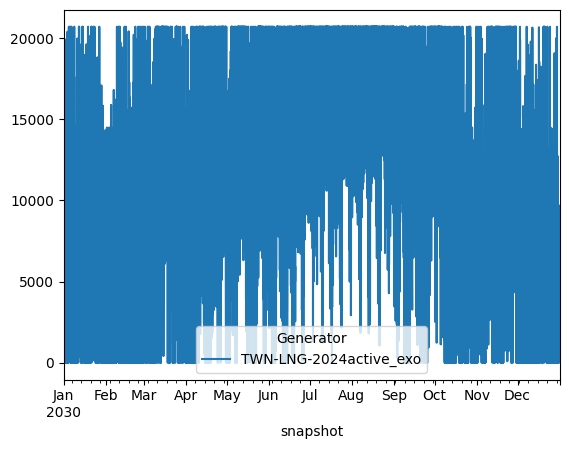

In [5]:
n.generators_t.p[['TWN-CoGen_biogas_waste-2024active_exo']].plot()

In [6]:
n.statistics.expanded_capacity(groupby=['bus', 'name', 'type'])

component    bus  name                                   type                     
Generator    TWN  TWN-Biomass-2024active_exo             biomass-unspecified          0.0
                  TWN-Biomass-2030_exo                   biomass-unspecified          0.0
                  TWN-CoGen_biogas_waste-2024active_exo  biogas_waste-cogeneration    0.0
                  TWN-CoGen_coal-2024active_exo          coal-cogeneration            0.0
                  TWN-Coal-2024active_exo                coal-unspecified             0.0
                  TWN-Geothermal-2024active_exo          geothermal-unspecified       0.0
                  TWN-Geothermal-2030_exo                geothermal-unspecified       0.0
                  TWN-Hydro-2024active_exo               hydro-unspecified            0.0
                  TWN-Hydro-2030_exo                     hydro-unspecified            0.0
                  TWN-LNG-2024active_exo                 gas-unspecified              0.0
                 

<Axes: xlabel='snapshot'>

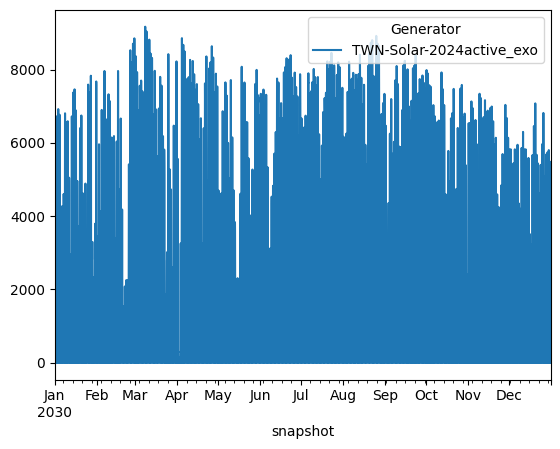

In [7]:
n.generators_t.p[['TWN-Solar-2024active_exo']].plot()


In [8]:
hourly_df = wrangle.transform_visualiser_hourly_output(n, pypsa_run_id='TWN-brownfield-003', market='Taiwan')
yearly_df = wrangle.transform_visualiser_yearly_output(n, pypsa_run_id='TWN-brownfield-003', market='Taiwan')


In [9]:
hourly_df.to_csv('Taiwan_brownfield_hourly_003.csv', index=False)
yearly_df.to_csv('Taiwan_brownfield_yearly_003.csv', index=False)


In [10]:
n.storage_units

,bus,control,type,p_nom,p_nom_mod,p_nom_extendable,p_nom_min,p_nom_max,p_min_pu,p_max_pu,...,cyclic_state_of_charge,cyclic_state_of_charge_per_period,max_hours,efficiency_store,efficiency_dispatch,standing_loss,inflow,p_nom_opt,annual_fixed_costs,total_capital_cost
StorageUnit,,,,,,,,,,,,,,,,,,,,,
TWN-PumpedHydro-2024active_exo,TWN,PQ,PumpedHydro,2602.0,0.0,False,0.0,0.00,-1.0,1.0,...,False,True,8.0,0.80,0.80,0.0,0.0,2602.0,20150,4019715.267
TWN-PumpedHydro-2030_endo,TWN,PQ,PumpedHydro,0.0,0.0,True,0.0,0.00,-1.0,1.0,...,False,True,8.0,0.80,0.80,0.0,0.0,-0.0,20150,4019715.267
TWN-PumpedHydro-2030_exo,TWN,PQ,PumpedHydro,0.0,0.0,False,0.0,0.00,-1.0,1.0,...,False,True,8.0,0.80,0.80,0.0,0.0,0.0,20150,4019715.267
TWN-Batteries-2024active_exo,TWN,PQ,Batteries,432.0,0.0,False,0.0,0.00,-1.0,1.0,...,False,True,2.0,0.95,0.95,0.0,0.0,432.0,32504,1791537.000
TWN-Batteries-2030_endo,TWN,PQ,Batteries,0.0,0.0,True,0.0,595.77,-1.0,1.0,...,False,True,6.0,0.95,0.95,0.0,0.0,-0.0,32504,1791537.000
TWN-Batteries-2030_exo,TWN,PQ,Batteries,1553.9,0.0,False,0.0,0.00,-1.0,1.0,...,False,True,6.0,0.95,0.95,0.0,0.0,1553.9,32504,1791537.000


<Axes: xlabel='snapshot'>

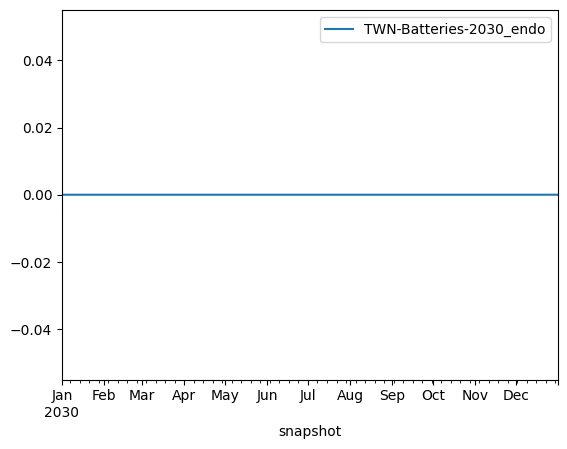

In [11]:
n.storage_units_t.p[['TWN-Batteries-2030_endo']].plot()